# Exploratory Visual Analysis of Housing Prices

**Dataset:** `housing_data.csv`  
**Target:** `SalePrice`  
**Tools:** Python, Pandas, Matplotlib  

> **Project context**  
> A real estate analytics team wants a first visual report on historical house sales before moving to modelling. The goal is to understand the housing market, identify the most important price drivers, and prepare a clean visual summary that can be presented to a stakeholder.


## Table of Contents

1. [About the Problem and Relevant Columns](#about-the-problem-and-relevant-columns)  
2. [Data Loading and Quick Inspection](#data-loading-and-quick-inspection)  
3. [Sale Price: Market Shape and Distribution](#sale-price-market-shape-and-distribution)  
4. [Property Size and Space Analysis](#property-size-and-space-analysis)  
5. [Location and Neighborhood Analysis](#location-and-neighborhood-analysis)  
6. [Quality and Condition Analysis](#quality-and-condition-analysis)  
7. [Age, Renovation, and Time Effects](#age-renovation-and-time-effects)  
8. [Relationships and Outliers](#relationships-and-outliers)  
9. [Final Visual Summary](#final-visual-summary)  
10. [Class Practice Tasks](#class-practice-tasks)


## About the Problem and Relevant Columns

The dataset contains **1,460 housing records** and **81 columns**. Each row represents one property sale. The main objective is to understand what appears to influence `SalePrice` and how the housing market behaves across different property types, locations, sizes, and quality levels.

### Why this dataset works well for visual analysis

This dataset is suitable for a classroom EDA notebook because it contains:

- a clear target variable: `SalePrice`
- several numerical features for distribution and relationship analysis
- several categorical features for grouping and comparison
- location-based variables that support real estate storytelling
- quality and condition variables that make box plots and grouped comparisons meaningful
- age and renovation variables that support timeline-style reasoning

### Relevant columns for this analysis

**Target**
- `SalePrice`

**Location and market segment**
- `Neighborhood`, `MSZoning`, `LotConfig`, `LandContour`, `Condition1`, `Condition2`, `BldgType`

**Property size and space**
- `LotFrontage`, `LotArea`, `GrLivArea`, `TotalBsmtSF`, `1stFlrSF`, `2ndFlrSF`, `LowQualFinSF`, `GarageArea`, `GarageCars`, `MasVnrArea`

**Quality and condition**
- `OverallQual`, `OverallCond`, `ExterQual`, `ExterCond`, `KitchenQual`, `HeatingQC`, `GarageQual`, `GarageCond`, `FireplaceQu`, `BsmtQual`, `BsmtCond`

**Age, construction, and renovation**
- `YearBuilt`, `YearRemodAdd`, `YrSold`, `MoSold`

**Structure and style**
- `HouseStyle`, `Foundation`, `RoofStyle`, `Exterior1st`, `Exterior2nd`, `SaleCondition`, `SaleType`, `CentralAir`

**Columns to treat carefully**
- `Unnamed: 0` behaves like an index column and should not be used as a feature
- `Alley`, `MasVnrType`, `GarageYrBlt`, and `Electrical` contain missing values and may need handling later

### Story for the notebook

The notebook follows the work of a real estate analyst who has been asked to prepare an initial visual report. The report should explain the price distribution, identify the main property segments, compare important categories, and highlight unusual cases before any predictive modelling begins.

### Analysis focus

The notebook is organized around these questions:

- What does the housing market look like overall?
- Which property features show useful variation?
- Which neighborhoods and property types stand out?
- Which quality and size features appear linked to price?
- Which visual patterns should be investigated further?


```python
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("default")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 11

df = pd.read_csv("housing_data.csv")
df.head()
```

In [72]:
! pip install matplotlib

In [73]:
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("default")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 11

df = pd.read_csv("/Users/shubhamkeshari/Desktop/project/python/Data_viz/housing_data.csv")
df.head()

,Unnamed: 0,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,0,SC60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,No,No,No,0,Feb,2008,WD,Normal,208500
1,1,SC20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,No,No,No,0,May,2007,WD,Normal,181500
2,2,SC60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,No,No,No,0,Sep,2008,WD,Normal,223500
3,3,SC70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,No,No,No,0,Feb,2006,WD,Abnorml,140000
4,4,SC60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,No,No,No,0,Dec,2008,WD,Normal,250000


## Data Loading and Quick Inspection

Before plotting anything, it is important to check the data structure, feature types, and missing values.

### What should be checked here

- number of rows and columns
- column names
- numeric versus categorical features
- missing values
- duplicate or index-like columns
- obvious data quality issues

### Questions for analysis

1. How many observations and features are available?  
   **Hint:** Use `df.shape`.

2. Which columns are numerical and which are categorical?  
   **Hint:** Use `df.dtypes` or `df.select_dtypes()`.

3. Which columns have missing values?  
   **Hint:** Use `df.isna().sum().sort_values(ascending=False)`.

4. Does `Unnamed: 0` behave like a real feature?  
   **Hint:** Compare it with the row index idea; it usually should not be used in plots.

5. Which variables look most promising for the first round of visual analysis?  
   **Hint:** Prioritize `SalePrice`, `GrLivArea`, `OverallQual`, `Neighborhood`, `YearBuilt`, and `TotalBsmtSF`.


In [74]:
# Q1
df.shape

(1460, 81)

In [75]:
#q2
df.dtypes

Unnamed: 0         int64
MSSubClass           str
MSZoning             str
LotFrontage      float64
LotArea            int64
                  ...   
MoSold               str
YrSold             int64
SaleType             str
SaleCondition        str
SalePrice          int64
Length: 81, dtype: object

In [76]:
df.select_dtypes('datetime')

""
0
1
2
3
4
...
1455
1456
1457
1458


In [77]:
#3. Which columns have missing values?
df.isnull().sum()

Unnamed: 0       0
MSSubClass       0
MSZoning         0
LotFrontage      0
LotArea          0
                ..
MoSold           0
YrSold           0
SaleType         0
SaleCondition    0
SalePrice        0
Length: 81, dtype: int64

In [78]:
# 4.Does Unnamed: 0 behave like a real feature?

df.columns

Index(['Unnamed: 0', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea',
       'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig',
       'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
       'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd',
       'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
       'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1',
       'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual',
       'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType',
       'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual',
       'GarageCond', 'Pa

In [79]:
df['Unnamed: 0']

0          0
1          1
2          2
3          3
4          4
        ... 
1455    1455
1456    1456
1457    1457
1458    1458
1459    1459
Name: Unnamed: 0, Length: 1460, dtype: int64

In [80]:
# Since Unnamed column behaves like Index and we already have index, therefore not required
df.drop(columns=['Unnamed: 0'], inplace=True)

In [81]:
df.head()

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,SC60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,No,No,No,0,Feb,2008,WD,Normal,208500
1,SC20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,...,0,No,No,No,0,May,2007,WD,Normal,181500
2,SC60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,...,0,No,No,No,0,Sep,2008,WD,Normal,223500
3,SC70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,...,0,No,No,No,0,Feb,2006,WD,Abnorml,140000
4,SC60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,...,0,No,No,No,0,Dec,2008,WD,Normal,250000


## Sale Price: Market Shape and Distribution

`SalePrice` is the target variable. Before comparing other features, the shape of the price distribution must be understood.

### What to look for

- common price range
- spread of the market
- skewness
- unusually expensive houses
- the difference between mean and median

### Questions for analysis

1. What is the overall distribution of `SalePrice`?  
   **Hint:** Use a **histogram** with a clear bin setting.

2. Is the sale price distribution symmetric or skewed?  
   **Hint:** Use the histogram shape and compare the left and right tails.

3. Are there extreme values in sale price?  
   **Hint:** Use a **box plot** to detect outliers.

4. Where do the mean and median fall in the price distribution?  
   **Hint:** Add reference lines on the histogram.

5. What does the distribution suggest about the market segment in this dataset?  
   **Hint:** Look for a long right tail or a concentrated middle band.


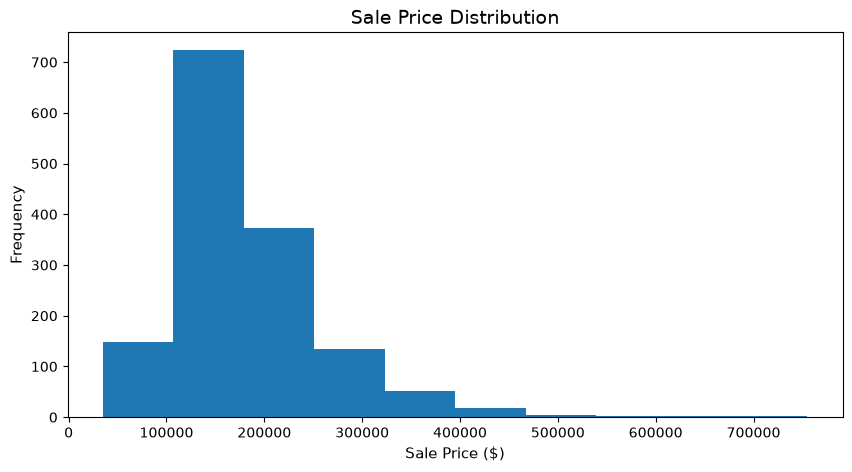

In [82]:
#1. What is the overall distribution of SalePrice?
plt.figure()
plt.hist(df.SalePrice)

plt.title('Sale Price Distribution')
plt.xlabel('Sale Price ($)')
plt.ylabel('Frequency')


plt.show()

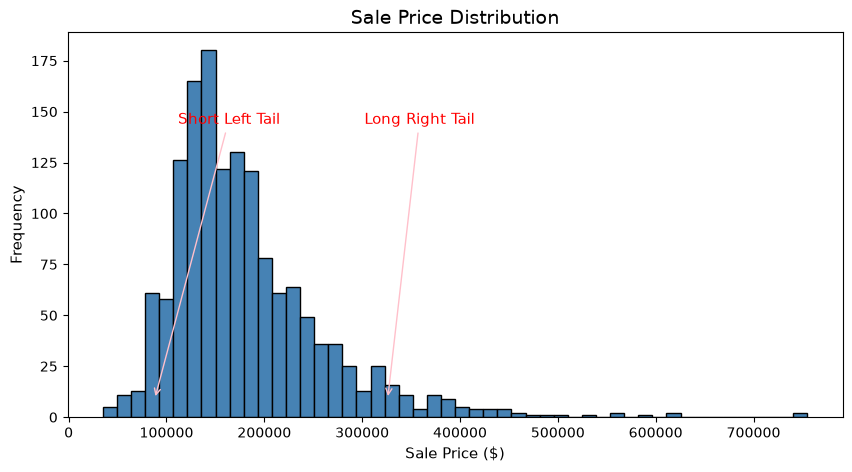

Skewness =  1.8828757597682129


In [83]:
# 2. Is the sale price distribution symmetric or skewed?

import numpy as np

plt.figure(figsize=(10,5))
n, bins, patches = plt.hist(df.SalePrice, bins=50, color='steelblue', edgecolor='black' )

plt.title('Sale Price Distribution')
plt.xlabel('Sale Price ($)')
plt.ylabel('Frequency')

# Calculate percentiles for annotation x-coordinates
left_tail_percentile = df.SalePrice.quantile(0.05)
right_tail_percentile = df.SalePrice.quantile(0.95)

# Determine appropriate y-coordinates for annotations
max_freq = np.max(n)
y_text_height = max_freq * 0.8 # y-coordinate for the annotation text
y_arrow_point = max_freq * 0.05 # y-coordinate where the arrow points on the histogram

# Calculate appropriate x-coordinates for the annotation text for correct pointing
diff_percentiles = right_tail_percentile - left_tail_percentile
xytext_left_x = left_tail_percentile + diff_percentiles * 0.1 # Text to the right of left tail
xytext_right_x = right_tail_percentile - diff_percentiles * 0.1 # Text to the left of right tail

# Annotate Short Left Tail
plt.annotate(
    "Short Left Tail",
    xy=(left_tail_percentile, y_arrow_point),
    xytext=(xytext_left_x, y_text_height),
    arrowprops=dict(arrowstyle = '->', color = 'pink'),
    fontsize = 11, color='Red'
)

# Annotate Long Right Tail
plt.annotate(
    "Long Right Tail",
    xy=(right_tail_percentile, y_arrow_point),
    xytext=(xytext_right_x, y_text_height),
    arrowprops=dict(arrowstyle = '->', color = 'pink'),
    fontsize = 11, color='Red'
)

plt.show()

print("Skewness = ",df.SalePrice.skew())


/var/folders/f7/6ttbslv14mb1smgbhyrcq1xh0000gn/T/ipykernel_22912/2778742147.py:5: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df.SalePrice, vert=False, patch_artist = True)


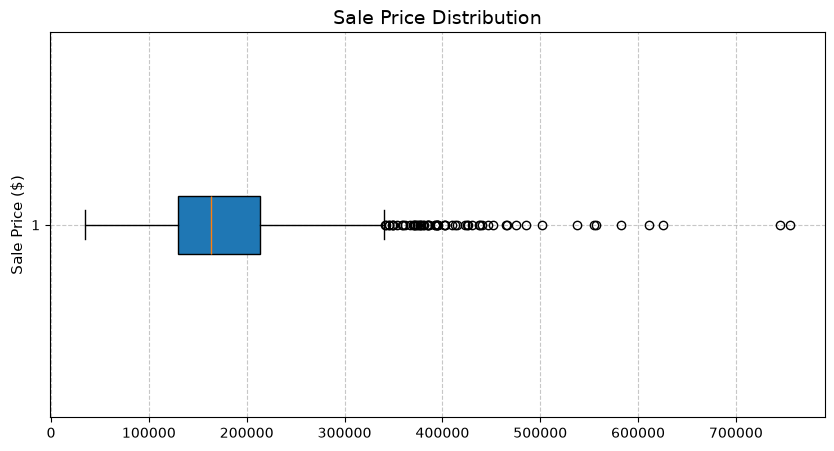

In [84]:
# 3. Are there extreme values in sale price?

plt.figure(figsize=(10,5))

plt.boxplot(df.SalePrice, vert=False, patch_artist = True)

plt.title('Sale Price Distribution')
plt.ylabel('Sale Price ($)')

plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()
plt.show()

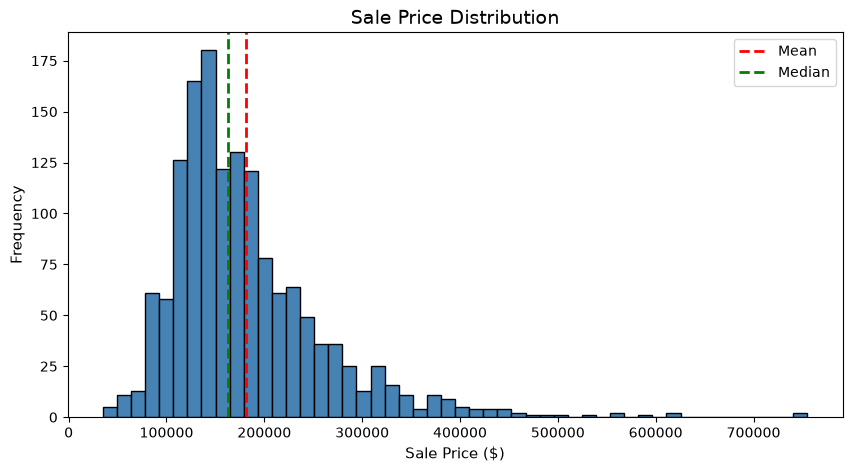

In [85]:
# 4. Where do the mean and median fall in the price distribution?

plt.figure(figsize=(10,5))

plt.hist(df.SalePrice, bins=50, color='steelblue', edgecolor='black' )

plt.axvline(df.SalePrice.mean(), color='red', linestyle='dashed', linewidth=2, label='Mean')
plt.axvline(df.SalePrice.median(), color='green', linestyle='dashed', linewidth=2, label='Median')




plt.title('Sale Price Distribution')
plt.xlabel('Sale Price ($)')
plt.ylabel('Frequency')

plt.legend()
plt.show()

In [86]:

#5. What does the distribution suggest about the market segment in this dataset?


### Observations on Sale Price Distribution

Based on the analysis of the `SalePrice` distribution:

*   **Skewness:** The distribution is highly **right-skewed**, as indicated by the histogram and a skewness value of approximately `1.88`. This means there is a longer tail on the higher price end, suggesting a presence of more expensive properties pulling the average up.
*   **Extreme Values/Outliers:** The box plot clearly shows a significant number of **outliers** on the higher end of the `SalePrice` spectrum. These represent homes sold at exceptionally high prices compared to the majority.
*   **Mean vs. Median:** Due to the right-skewness and the presence of high-value outliers, the **mean (`SalePrice` ~ 180,921)** is notably **higher than the median (`SalePrice` ~ 163,000)**. The median provides a better representation of the typical sale price in this market, as it is less affected by extreme values.
*   **Market Segment Suggestion:** The distribution suggests a market with a solid base of moderately priced homes, but also a distinct segment of high-value properties that significantly influence the overall average. This could indicate a diverse housing market catering to various income levels, with a luxury segment driving the upper tail.

## Property Size and Space Analysis

Property size is one of the first areas to examine in housing data. Larger homes often sell for more, but not every size measure has the same meaning.

### Features to compare

- `LotArea`
- `LotFrontage`
- `GrLivArea`
- `TotalBsmtSF`
- `1stFlrSF`
- `2ndFlrSF`
- `GarageArea`
- `GarageCars`

### Questions for analysis

1. Does larger living area correspond to higher sale price?  
   **Hint:** Use a **scatter plot** of `GrLivArea` versus `SalePrice`.

2. Does lot size behave the same way as living area?  
   **Hint:** Compare `LotArea` with `SalePrice` using a **scatter plot**.

3. Does basement area appear related to sale price?  
   **Hint:** Use a **scatter plot** or a **small subplot panel** for size variables.

4. Do garage size and garage capacity show a visible price effect?  
   **Hint:** Compare `GarageArea` and `GarageCars` against `SalePrice`.

5. Which size feature appears most informative at first glance?  
   **Hint:** Place several scatter plots side by side and compare the pattern strength.

6. Are there unusually large homes with relatively low prices or small homes with unusually high prices?  
   **Hint:** Look for outliers in **scatter plots** and **box plots**.


In [87]:
# Relationship between GrLivArea and SalePrice
df[['GrLivArea', 'SalePrice']].describe()

,GrLivArea,SalePrice
count,1460.000000,1460.000000
mean,1515.463699,180921.195890
std,525.480383,79442.502883
min,334.000000,34900.000000
25%,1129.500000,129975.000000
50%,1464.000000,163000.000000
75%,1776.750000,214000.000000
max,5642.000000,755000.000000


In [88]:
# Corelation
df[['GrLivArea', 'SalePrice']].corr()

,GrLivArea,SalePrice
GrLivArea,1.000000,0.708624
SalePrice,0.708624,1.000000


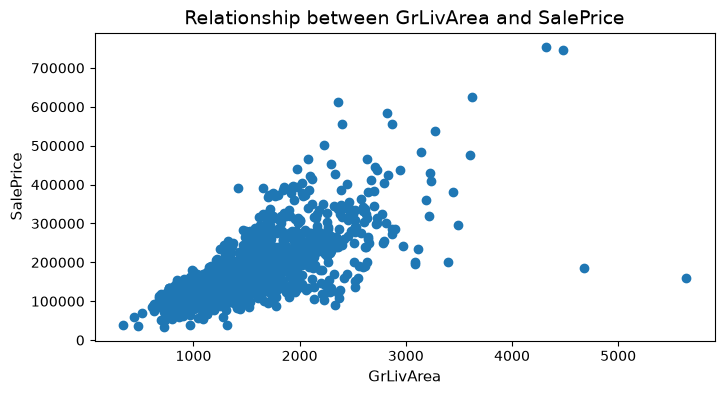

In [89]:
# scatter plot
plt.figure(figsize=(8,4))
plt.scatter(df.GrLivArea, df.SalePrice)

plt.title('Relationship between GrLivArea and SalePrice')
plt.xlabel('GrLivArea')
plt.ylabel('SalePrice')

plt.show()

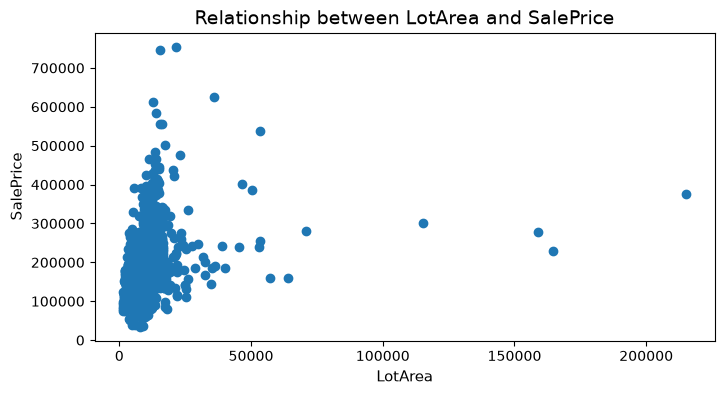

In [90]:

# 2. Does lot size behave the same way as living area?

plt.figure(figsize=(8,4))
plt.scatter(df.LotArea, df.SalePrice)

plt.title('Relationship between LotArea and SalePrice')
plt.xlabel('LotArea')
plt.ylabel('SalePrice')

plt.show()

In [91]:
df[['LotArea', 'SalePrice']].corr()


,LotArea,SalePrice
LotArea,1.000000,0.263843
SalePrice,0.263843,1.000000


In [92]:
# Does basement area appear related to sale price?
df[['TotalBsmtSF', 'SalePrice']].corr()


,TotalBsmtSF,SalePrice
TotalBsmtSF,1.000000,0.613581
SalePrice,0.613581,1.000000


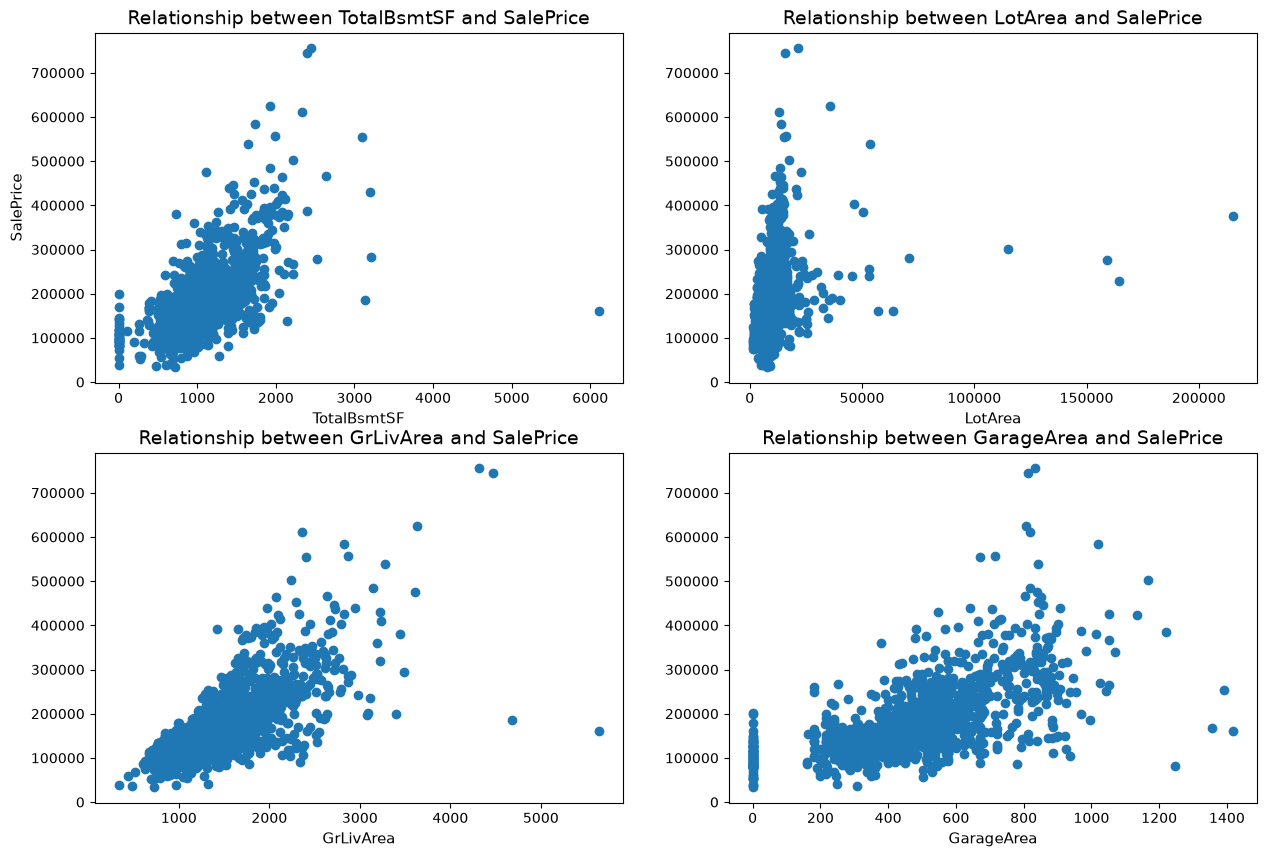

In [93]:
# Hint: Use a scatter plot or a small subplot panel for size variables.

# Sub-plot
plt.figure(figsize=(15,10))

plt.subplot(2,2,1)
plt.scatter(df.TotalBsmtSF, df.SalePrice)
plt.title('Relationship between TotalBsmtSF and SalePrice')
plt.xlabel('TotalBsmtSF')
plt.ylabel('SalePrice')

plt.subplot(2,2,2)
plt.scatter(df.LotArea, df.SalePrice)
plt.title('Relationship between LotArea and SalePrice')
plt.xlabel('LotArea')

plt.subplot(2,2,3)
plt.scatter(df.GrLivArea, df.SalePrice)
plt.title('Relationship between GrLivArea and SalePrice')
plt.xlabel('GrLivArea')

plt.subplot(2,2,4)
plt.scatter(df.GarageArea, df.SalePrice)
plt.title('Relationship between GarageArea and SalePrice')
plt.xlabel('GarageArea')
plt.show()

In [94]:
# garage cars
df[['GarageArea', 'GarageCars', 'SalePrice']].corr()

,GarageArea,GarageCars,SalePrice
GarageArea,1.000000,0.882475,0.623431
GarageCars,0.882475,1.000000,0.640409
SalePrice,0.623431,0.640409,1.000000


In [95]:
# garage cars
df.GarageCars.value_counts()

GarageCars
2    824
1    369
3    181
0     81
4      5
Name: count, dtype: int64

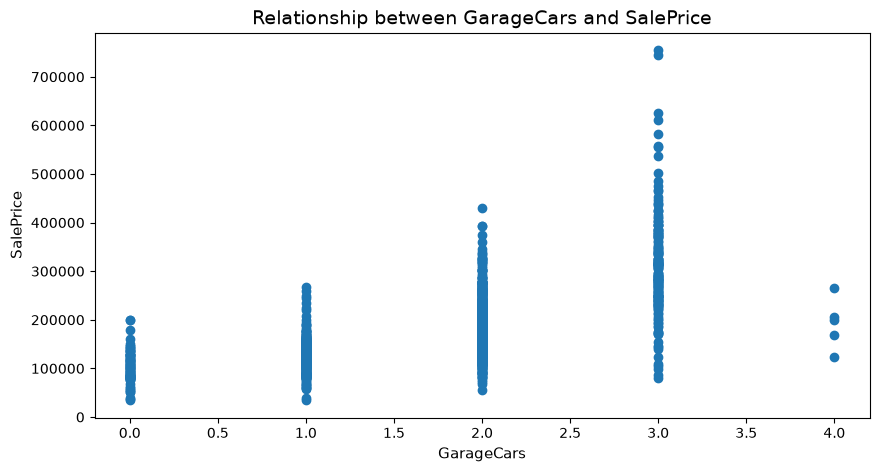

In [96]:
plt.scatter(df.GarageCars, df.SalePrice)
plt.title('Relationship between GarageCars and SalePrice')
plt.xlabel('GarageCars')
plt.ylabel('SalePrice')
plt.show()

In [97]:
# GarageCars vs SalePrice groupby
df.groupby('GarageCars').SalePrice.mean()

GarageCars
0    103317.283951
1    128116.688347
2    183851.663835
3    309636.121547
4    192655.800000
Name: SalePrice, dtype: float64

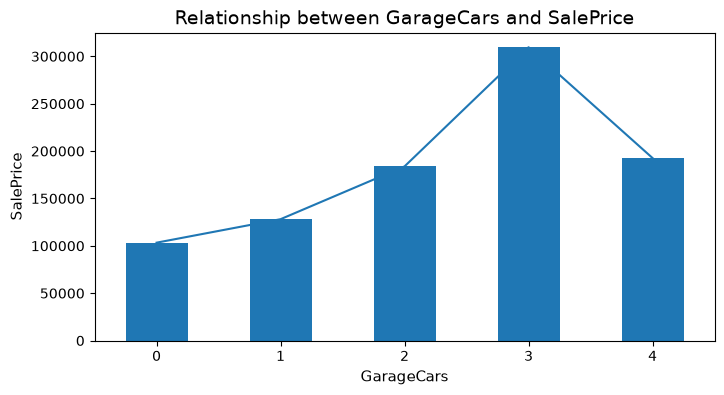

In [98]:
# graph of Bar Charts
plt.figure(figsize=(8,4))
df.groupby('GarageCars').SalePrice.mean().plot(kind='bar')
df.groupby('GarageCars').SalePrice.mean().plot(kind='line')

plt.title('Relationship between GarageCars and SalePrice')
plt.xlabel('GarageCars')
plt.ylabel('SalePrice')
plt.show()

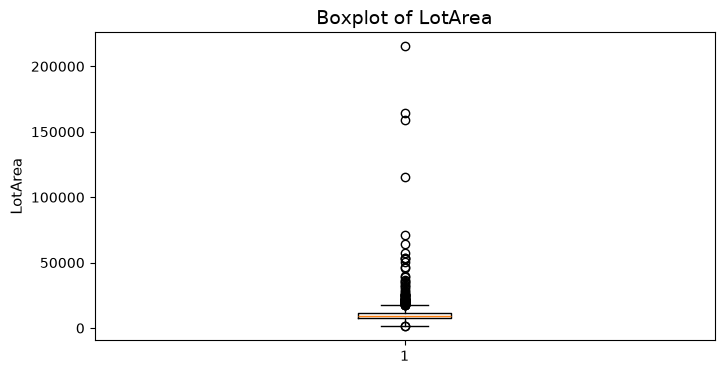

Lower Bound 1481.5
Upper Bound 17673.5
IQR 4048.0
Outliers 53      50271
66      19900
113     21000
120     21453
159     19378
        ...  
1396    57200
1409    20544
1423    19690
1430    21930
1446    26142
Name: LotArea, Length: 69, dtype: int64


In [99]:
# 6. Are there unusually large homes with relatively low prices or small homes with unusually high prices?
lot_area_q1 = df.LotArea.quantile(0.25)
lot_area_q3 = df.LotArea.quantile(0.75)
lot_area_iqr = lot_area_q3 - lot_area_q1

lower_bound = lot_area_q1 - 1.5 * lot_area_iqr
upper_bound = lot_area_q3 + 1.5 * lot_area_iqr

# find the oultliers and saleprice of them
df_outliers = df[(df.LotArea < lower_bound) | (df.LotArea > upper_bound)]

#boxplot of lot area
plt.figure(figsize=(8,4))
plt.boxplot(df.LotArea)
plt.title('Boxplot of LotArea')
plt.ylabel('LotArea')
plt.show()

print("Lower Bound", lower_bound)
print("Upper Bound", upper_bound)
print("IQR", lot_area_iqr)
print("Outliers", df_outliers.LotArea)

In [100]:
# corelation between outlier areas and price
df_outliers[['LotArea', 'SalePrice']].corr()

,LotArea,SalePrice
LotArea,1.000000,0.199763
SalePrice,0.199763,1.000000


Text(0, 0.5, 'SalePrice')

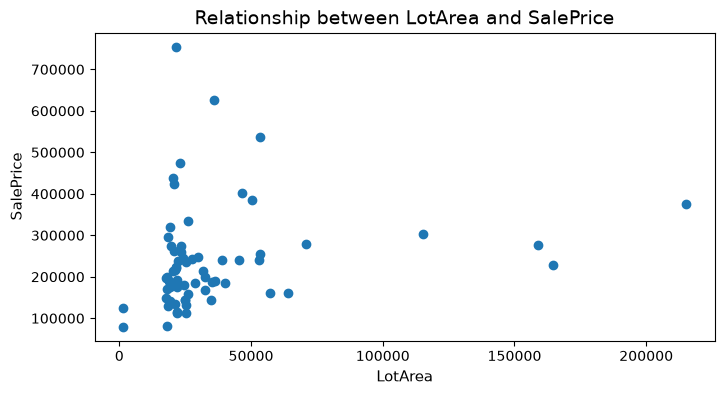

In [101]:
# plot it
plt.figure(figsize=(8,4))
plt.scatter(df_outliers.LotArea, df_outliers.SalePrice)
plt.title('Relationship between LotArea and SalePrice')
plt.xlabel('LotArea')
plt.ylabel('SalePrice')

### Observations on Property Size and Space Analysis

Based on the analysis of property size and space features in relation to `SalePrice`:

*   **`GrLivArea` (Above Grade Living Area):** This feature shows the strongest positive linear relationship with `SalePrice` (correlation coefficient of **0.71**). The scatter plot reveals a clear upward trend, indicating that larger living areas generally correspond to higher sale prices, with some high-value outliers.
*   **`TotalBsmtSF` (Total Basement Square Feet):** There is also a strong positive correlation between `TotalBsmtSF` and `SalePrice` (**0.61**). The scatter plot in the subplot panel reinforces this, showing that houses with larger basements tend to fetch higher prices.
*   **`GarageArea` and `GarageCars`:** Both `GarageArea` (correlation **0.62**) and `GarageCars` (correlation **0.64**) are strongly correlated with `SalePrice`. The bar chart for `GarageCars` shows a clear trend: as the number of cars a garage can hold increases from 0 to 3, the average sale price significantly rises. There's a slight drop for 4-car garages, but the overall pattern is strong.
*   **`LotArea` (Lot Size):** While `LotArea` has a positive correlation with `SalePrice` (**0.26**), it is considerably weaker than `GrLivArea` or garage-related features. The scatter plot for `LotArea` appears much more dispersed, and the box plot identified numerous outliers in lot area. The correlation with `SalePrice` for these outliers is even weaker (**0.19**), suggesting that extremely large lots don't necessarily guarantee a proportionally higher sale price, and the relationship is less straightforward.
*   **Outliers in `LotArea`:** The analysis identified several properties with unusually large `LotArea` values (outliers). Their `SalePrice` doesn't always scale proportionally, indicating that beyond a certain point, lot size has a diminishing impact on price, or other factors become more dominant.

In summary, `GrLivArea`, `TotalBsmtSF`, and garage capacity (`GarageCars`/`GarageArea`) are strong indicators of `SalePrice`, showing clear positive relationships. `LotArea`, while related, has a weaker and more dispersed relationship, with outliers not necessarily translating to significantly higher prices.


## Location and Neighborhood Analysis

Location is one of the strongest real estate factors. In this dataset, `Neighborhood` is the most useful location variable for first-pass analysis.

### What to compare

- sale price by neighborhood
- property counts by neighborhood
- zoning categories
- lot configuration
- land contour and slope

### Questions for analysis

1. Which neighborhoods contain the most properties?  
   **Hint:** Use a **horizontal bar chart** sorted by frequency.

2. Which neighborhoods have the highest typical sale prices?  
   **Hint:** Use a **box plot** of `SalePrice` grouped by `Neighborhood`.

3. Are expensive neighborhoods also rare in the dataset?  
   **Hint:** Compare a frequency chart with a price chart.

4. Do zoning categories show clear price differences?  
   **Hint:** Use a **bar chart** of average or median `SalePrice` by `MSZoning`.

5. Does the lot configuration seem connected to price patterns?  
   **Hint:** Use a **bar chart** or **box plot** for categorical comparison.

6. Which location variable gives the clearest business insight in one view?  
   **Hint:** Choose the chart that separates groups most clearly.


In [102]:
# Which neighborhoods contain the most properties?
neighborhood_counts = df.Neighborhood.value_counts().sort_values(ascending=False)

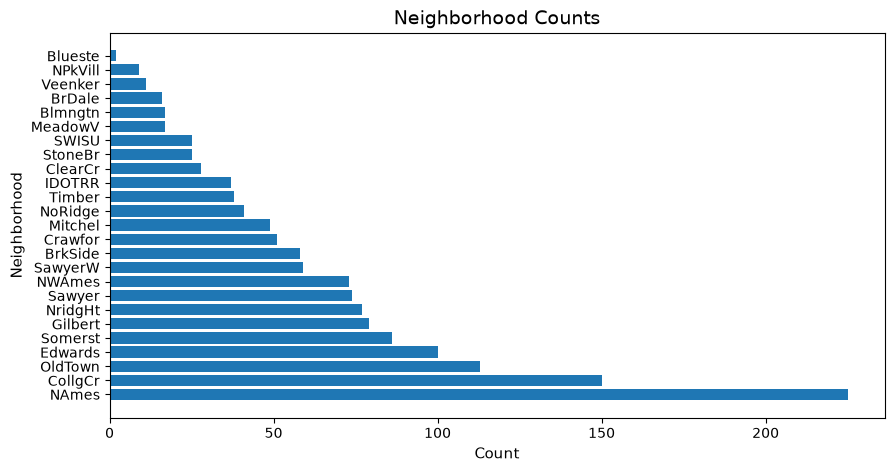

In [103]:
plt.figure(figsize=(10,5))

plt.barh(neighborhood_counts.index, neighborhood_counts)

plt.title('Neighborhood Counts')
plt.xlabel('Count')
plt.ylabel('Neighborhood')

plt.show()

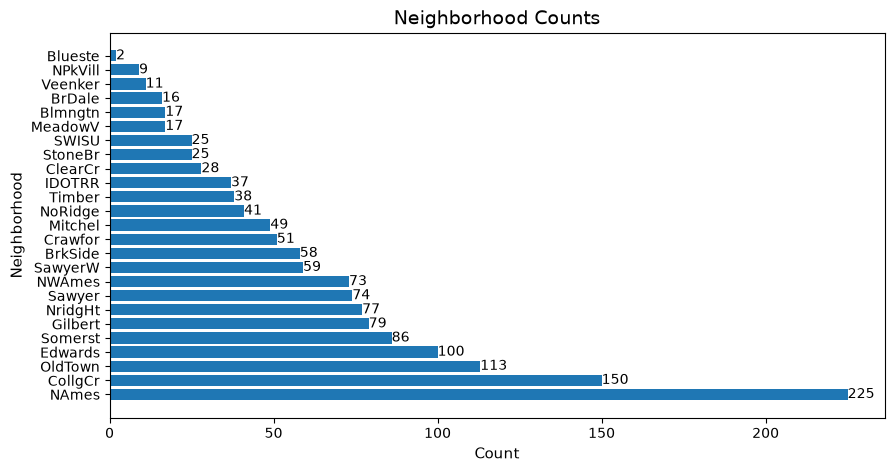

In [104]:
bars = plt.barh(neighborhood_counts.index, neighborhood_counts)
plt.bar_label(bars)

plt.title('Neighborhood Counts')
plt.xlabel('Count')
plt.ylabel('Neighborhood')

plt.show()

<Figure size 1400x1000 with 0 Axes>

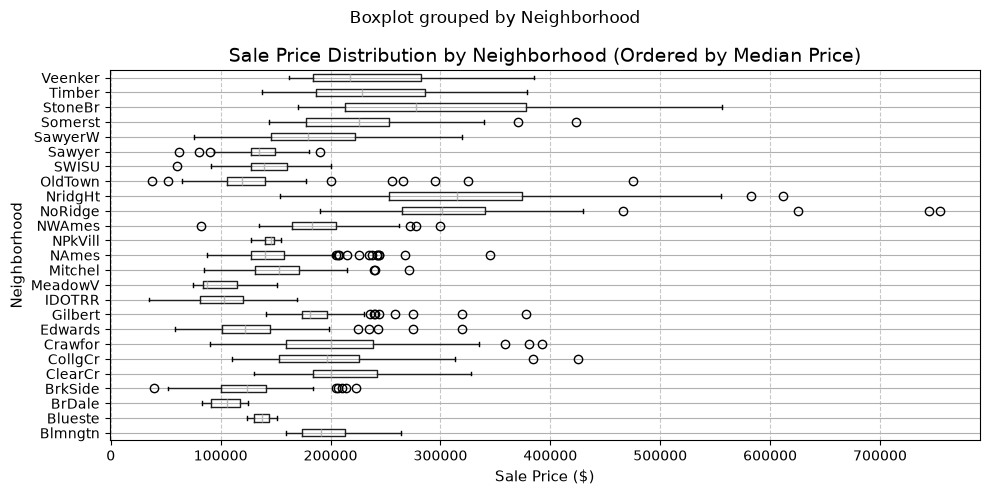

In [105]:
import seaborn as sns

# Order neighborhoods by median SalePrice (highest to lowest)
order = df.groupby('Neighborhood')['SalePrice'].median().sort_values(ascending=False).index

plt.figure(figsize=(14, 10)) # Increased figure height for better readability
df.boxplot('SalePrice','Neighborhood', vert=False, positions=range(len(order)))

plt.title('Sale Price Distribution by Neighborhood (Ordered by Median Price)')
plt.xlabel('Sale Price ($)')
plt.ylabel('Neighborhood')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout() # Adjust layout to prevent labels from overlapping
plt.show()

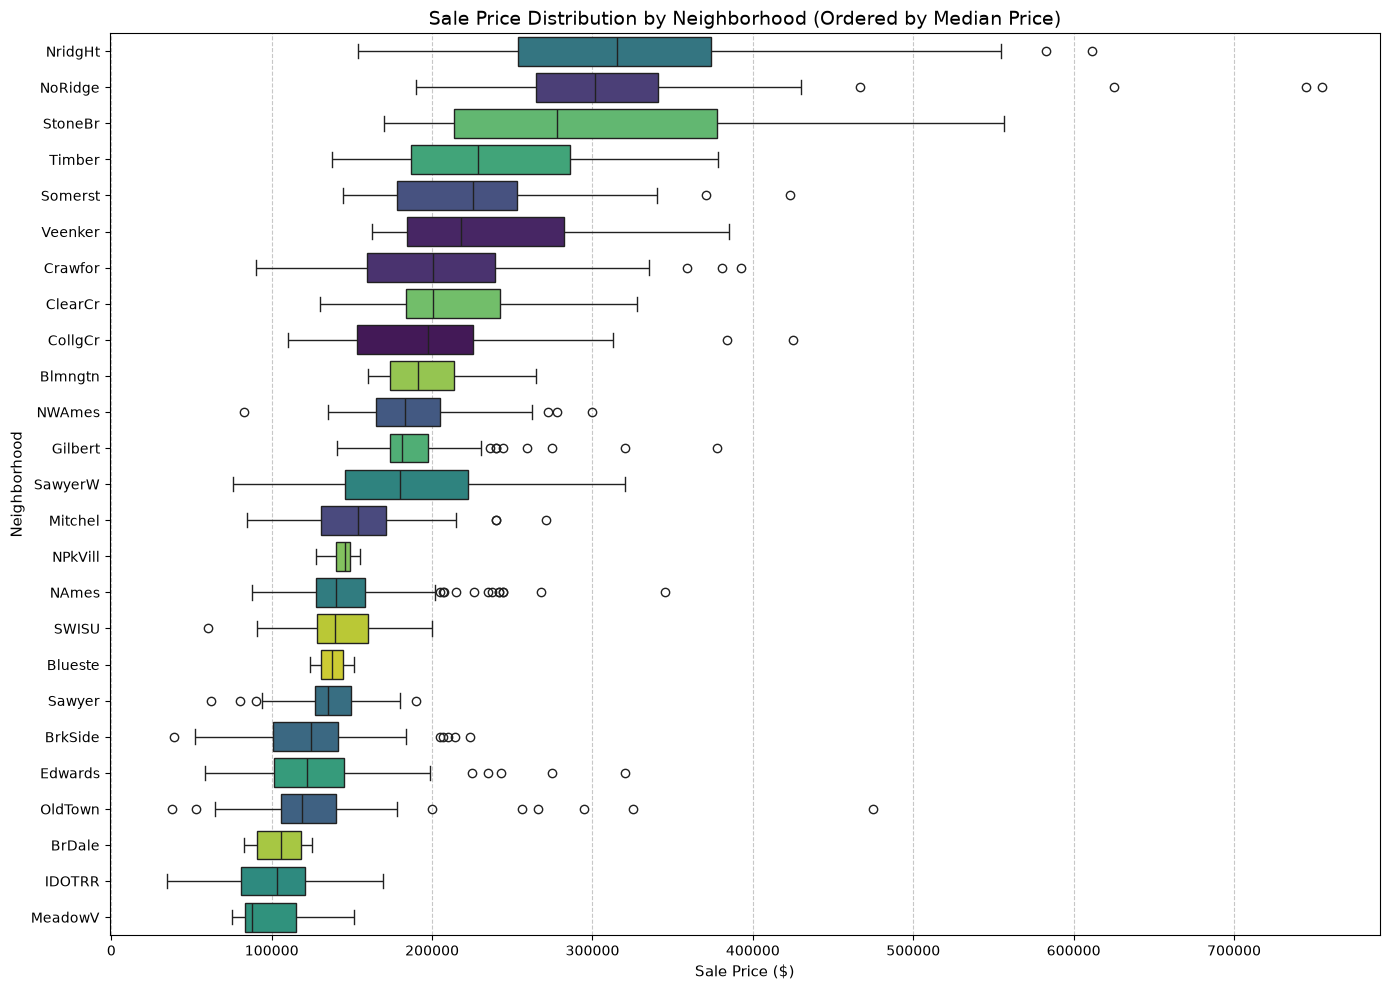

In [106]:
# Which neighborhoods have the highest typical sale prices?
# Hint: Use a box plot of SalePrice grouped by Neighborhood.

import seaborn as sns

# Order neighborhoods by median SalePrice (highest to lowest)
order = df.groupby('Neighborhood')['SalePrice'].median().sort_values(ascending=False).index

plt.figure(figsize=(14, 10)) # Increased figure height for better readability
sns.boxplot(x='SalePrice', y='Neighborhood', data=df, order=order, palette='viridis', hue='Neighborhood', legend=False)

plt.title('Sale Price Distribution by Neighborhood (Ordered by Median Price)')
plt.xlabel('Sale Price ($)')
plt.ylabel('Neighborhood')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout() # Adjust layout to prevent labels from overlapping
plt.show()

## Quality and Condition Analysis

Quality variables often explain price better than raw size alone. These features are useful for grouped comparison and box plot practice.

### Features to study

- `OverallQual`
- `OverallCond`
- `ExterQual`
- `ExterCond`
- `KitchenQual`
- `HeatingQC`
- `GarageQual`
- `GarageCond`
- `BsmtQual`
- `BsmtCond`
- `FireplaceQu`

### Questions for analysis

1. Does higher overall quality correspond to higher sale price?  
   **Hint:** Use a **box plot** of `SalePrice` by `OverallQual`.

2. Does overall condition follow the same pattern as overall quality?  
   **Hint:** Compare `OverallCond` with `OverallQual` using separate visuals.

3. Which quality feature appears most strongly related to price?  
   **Hint:** Use grouped **box plots** or **bar charts** for comparison.

4. Are higher quality homes also more consistent in price?  
   **Hint:** Check the spread within each quality group using a **box plot**.

5. Do kitchen quality and exterior quality show visible pricing tiers?  
   **Hint:** Use **box plots** grouped by category levels.

6. Which visual best communicates quality differences to a business audience?  
   **Hint:** Prefer the chart that shows both central tendency and spread.


## Age, Renovation, and Time Effects

Age matters in property analysis. A home may be old, but renovated homes can still command strong prices.

### Features to examine

- `YearBuilt`
- `YearRemodAdd`
- `YrSold`
- `MoSold`

### Questions for analysis

1. Do newer homes generally sell for more?  
   **Hint:** Use a **scatter plot** of `YearBuilt` versus `SalePrice`.

2. Is renovation year related to a higher price?  
   **Hint:** Compare `YearRemodAdd` with `SalePrice` using a **scatter plot**.

3. Does sale year show a broad market shift in price?  
   **Hint:** Use a **line plot** or **bar chart** of average `SalePrice` by `YrSold`.

4. Does the month of sale show any recurring pattern?  
   **Hint:** Use a **bar chart** of average `SalePrice` by `MoSold`.

5. Do older homes always sell for less?  
   **Hint:** Use grouped visuals instead of assuming a straight-line effect.

6. Can renovation appear to offset age in some cases?  
   **Hint:** Compare age-related patterns against quality or condition visuals.


## Relationships and Outliers

This section brings together the most important relationships seen so far and checks for unusual values that may affect interpretation.

### Questions for analysis

1. Which numerical variables appear most strongly related to `SalePrice`?  
   **Hint:** Use several **scatter plots** in a **subplot layout**.

2. Which relationship looks most linear?  
   **Hint:** Compare `GrLivArea`, `TotalBsmtSF`, `GarageArea`, and `LotArea` against price.

3. Are there signs of non-linear behavior or diminishing returns?  
   **Hint:** Look at the shape of the scatter cloud, especially at higher values.

4. Which variables show obvious outliers?  
   **Hint:** Use **box plots** for the selected variables.

5. Are there homes that look unusual but still valid?  
   **Hint:** Combine scatter plots with box plots before deciding whether a value is suspicious.

6. Which outliers should be treated as rare market cases rather than data errors?  
   **Hint:** Use context from neighborhood, quality, and size features before concluding.


## Final Visual Summary

The final output should not be a random collection of plots. It should read like a compact visual report.

### Recommended visual set for the summary figure

- `SalePrice` histogram
- `SalePrice` box plot
- top neighborhoods by count
- average `SalePrice` by `Neighborhood`
- `SalePrice` vs `GrLivArea`
- `SalePrice` by `OverallQual`

### Questions for analysis

1. Which three visuals best summarize the housing market?  
   **Hint:** Choose visuals that cover distribution, comparison, and relationship.

2. Which chart best explains why some homes sell for much more than others?  
   **Hint:** Look at quality and living area.

3. Which chart best explains location differences?  
   **Hint:** Use neighborhood-level comparisons.

4. Which chart best shows unusual cases?  
   **Hint:** Use the box plot and scatter plot together.

5. What is the strongest business message from the analysis?  
   **Hint:** Write one short conclusion for price, one for size, and one for location.


## Class Practice Tasks

These tasks should be attempted by learners after the guided walkthrough.

### Practice tasks

1. Choose one categorical variable and compare `SalePrice` across its categories.  
   **Hint:** Use a **box plot** or **bar chart** depending on the number of categories.

2. Choose one numeric size variable and study its relation to `SalePrice`.  
   **Hint:** Use a **scatter plot**.

3. Choose one quality variable and explain how price changes across levels.  
   **Hint:** Use a **box plot**.

4. Create one figure with at least four subplots from the variables studied in class.  
   **Hint:** Include a mix of **histogram**, **box plot**, **scatter plot**, and **bar chart**.

5. Write five short observations from the visuals.  
   **Hint:** Each observation should mention a variable and a clear pattern.

6. Identify one chart that should be shown to a business stakeholder first.  
   **Hint:** Select the chart with the clearest practical message.


## Notebook Close

This notebook is designed to help learners move from simple plotting to real exploratory analysis. The goal is to read the data visually, compare important groups, identify relationships, and turn the findings into a short business-style summary.
